# Check timeseries derived from flexpart output 
(different data weighted with footprints to obtain contribution at Mt. Kenya)

In [1]:
# import 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
from utils.utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt
from dateutil import tz
from suntime import Sun, SunTimeException

from plotting import tol_colors # color schemes from https://personal.sron.nl/~pault/
from utils import process_data
from utils.utilities import to_datetime

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

#save figures in...
dir_save = './output/'

# select time period
t1 = "2020-01-01"
t2 = "2023-12-31"

In [2]:
## Read all data
from input.read_wdc_data import AvailableData, create_data_reader

# File path
data_path = "../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


In [3]:
# remove outliers or not
remove_outliers = False #remove outliers based ont uncertainty and statistics
remove_fire_events = True # remove spcific fire events (defined below)

#-----
fire_dates_Mar2022 = slice('2022-03-16','2022-03-29')
fire_times_Mar2022 = ds_all.sel(time=fire_dates_Mar2022).time.values


fire_dates_Mar2021 = slice('2021-03-20','2021-03-28')
fire_times_Mar2021 = ds_all.sel(time=fire_dates_Mar2021).time.values

if remove_fire_events:
    # remove fire events from the dataset. Use a workaround, because xarray adds time dimension to all variables
    ds_withtime = ds_all.drop([ var for var in ds_all.variables if not 'time' in ds_all[var].dims ])
    ds_timeless = ds_all.drop([ var for var in ds_all.variables if     'time' in ds_all[var].dims ])
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2022)==False) #don't use the fire event times 2022
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2021)==False) #don't use the fire event times 2021
    ds_all_rem_out = xr.merge([ds_timeless, ds_withtime])

if remove_outliers:
    # Remove outliers that exceed 10*stdedeviation_mean and 4* the zscore 
    # remove outliers for each species sperarately
    ds_all_rem_out = ds_all.copy(deep=True) #use deepcopy, otherwise it replaces values in ds_all!
    outlier_masks = {}
    for ds in np.unique(ds_all.species):
        print(f"remove outliers for {ds}:")
        ds_all_rem_out.loc[dict(dataset=ds)], mask_removed_outliers= process_data.rem_out(ds_all.sel(dataset=ds), std_fac=10, z_threshold=4)
        outlier_masks[ds] = mask_removed_outliers

/tmp/ipykernel_1534074/1796778537.py:15: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_withtime = ds_all.drop([ var for var in ds_all.variables if not 'time' in ds_all[var].dims ])
/tmp/ipykernel_1534074/1796778537.py:16: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_timeless = ds_all.drop([ var for var in ds_all.variables if     'time' in ds_all[var].dims ])


### Read in Aerosol data

In [4]:
from input import read_aerosols
# Read in aerosol data and extract Black carbon
aerosol_data_dir = "../data/level2/L2_AEROSOL_data_bachelorthesis Mike Baumann"
ds_ae, ds_neph = read_aerosols.aerosol_data_to_dataset(aerosol_data_dir)

# make a full dataset with wavelength dependence and calculated aerosol properties (SAE, SSA, AAE)
ds_aerosols = read_aerosols.aerosols_to_full_dataset(ds_ae, ds_neph)

## Remove fire events/outliers from the aerosol data

if remove_fire_events:
    # remove fire events from the dataset. Use a workaround, because xarray adds time dimension to all variables
    ds_withtime = ds_aerosols.drop([ var for var in ds_aerosols.variables if not 'time' in ds_aerosols[var].dims ])
    ds_timeless = ds_aerosols.drop([ var for var in ds_aerosols.variables if     'time' in ds_aerosols[var].dims ])
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2022)==False) #don't use the fire event times 2022
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2021)==False) #don't use the fire event times 2021
    ds_aerosols_rem_out = xr.merge([ds_timeless, ds_withtime])

if remove_outliers:
    outlier_masks = {}
    for var_name in np.unique(list(ds_aerosols.keys())[0:4]):
        print(f"remove outliers for {var_name}:")
        drop_vars = list(ds_aerosols.keys())
        drop_vars.remove(var_name)
        ds_aer_removed_outliers, mask_aer_no_outliers = process_data.rem_out(ds_aerosols_rem_out.drop(drop_vars),vars=[var_name], use_unc=False, std_fac=10, z_threshold=6,plot_timeseries=False)
        ds_aerosols_rem_out[var_name] = ds_aer_removed_outliers[var_name]
        outlier_masks[var_name] = mask_aer_no_outliers

      

/newhome/leob/Documents/git-repos/gawkenya/analyses/input/read_aerosols.py:108: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df_ae = pd.read_csv(
/newhome/leob/Documents/git-repos/gawkenya/analyses/input/read_aerosols.py:117: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df_neph = pd.read_csv(
/bigdat/leob/kadi_py311/lib64/python3.11/site-packages/xarray/core/computation.py:824: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)
/bigdat/leob/kadi_py311/lib64/python3.11/site-packages/xarray/core/computation.py:824: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)
/bigdat/leob/kadi_py311/lib64/python3.11/site-package


### Use different background methods

In [5]:
# Define fit paramaters for the curve fitting (NOAA approach)
from utils.ccg_filter import ccg_filter as ccgfilt
from utils.ccg_filter import ccg_dates
from utils import run_curve_fit

# Default values
fit_params_defaults = {'shortterm': 80, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 3, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1 / 24,  # 1h
                'numharmonics': 4}

fit_properties = {}
for dataset in ds_all_rem_out.dataset:
    dataset_name = dataset.values.item()  # Convert numpy array to a hashable type
    fit_properties[dataset_name] = fit_params_defaults.copy()

In [6]:
## plot background for a single species, including the NOAA fit and NOAA MBL (marine boundary layer) data

def plot_background(    
        dataset_str: str, 
        t1: str,
        t2: str,
        mbl: pd.DataFrame | None = None,
        save_fig: bool = False,
        quantile_value = 10,
        mw = 1080,
    ) -> tuple[xr.DataArray,xr.DataArray] | tuple[xr.DataArray,xr.DataArray,xr.DataArray]:
    '''
    mw = moving window for running percentile:
    mw = 24 * 45 days (data given in hours)
    mbl = marine boundary layer dataframe

    Returns various background-time series for this given species
    '''

    ds_sel = ds_all_rem_out.sel(dataset=dataset_str, time=slice(t1, t2))

    fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    ax0 = axs[0]
    ax1 = axs[1]
    ds_sel.value.plot(marker=".", color="dimgrey", ls="", ax=ax0,zorder=0)
    percentile_10th = (
        ds_sel.value.rolling(time=mw, center=True).construct("tmp").quantile(quantile_value/100, dim="tmp")
    )
    plot_percentiles = percentile_10th.plot(
        marker=".", ls="-", color="k", lw=1,ax=ax0, label=f'moving {quantile_value}th percentile ({int(mw/24)}days)',zorder=2
    )  # take 3days windows and for each window the 10%-quantile
    # save the background data
    delta_to_background = ds_sel.value - percentile_10th

    # plot the NOAA fit for comparison
    filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                    ds=ds_sel.value,
                    dataset_str=dataset_str,
                    t1=t1,
                    t2=t2,
                    **fit_properties[dataset_str]
                )
    ds_sel['curve_fit'] = ds_interp["smoothed_vals"].resample(time='1h').mean()
    plot_noaa = ds_sel['curve_fit'].plot(ax=ax0,label='curve fit NOAA',color='orange',ls='--')
    # save the background data using NOAA
    delta_to_background_curvefit = ds_sel.value - ds_sel['curve_fit']

    
    # Plot the NOAA-MBL background (marine boundary layer)
    # It is only available for CO2 and CH4
    if isinstance(mbl,pd.DataFrame):
        mbl_background = mbl['value'].to_xarray().sel(time=slice(t1,t2))
        plot_mbl = mbl_background.plot(label='MBL',ax=ax0) # transform to xarray to have automatic time-axis alignment
        # save the background using MBL data as baseline
        delta_to_background_mbl =  ds_sel.value - mbl_background.resample(time='1h').interpolate() # interpolate the MBL data to 1h


    ## plot the background and the difference to this "background":
    # use percentiles as baseline:
    mask_is_background = ds_sel.value < percentile_10th
    #mask_is_background = mask_is_background_co ## use the CO background conditions

    # plot the "background" in light grey
    ds_sel.value[mask_is_background].plot(color='lightgrey',ls='',marker='.',ax=ax0,label='background percentiles',zorder=1)
    
    lgd0 = ax0.legend(bbox_to_anchor=(1.01, 0.5), loc='center left', ncol=1,fontsize=8)

    # ------ 2nd subplot ----- #
    ### plot data with removed background
    delta_to_background.where(delta_to_background > 0).plot(
        ax=ax1, color=plot_percentiles[0].get_color(),marker='.', label = 'removed percentile background'
    )  # plot all data that are larger than the "background" in new subplot
    delta_to_background_curvefit.where(delta_to_background_curvefit > 0).plot(
        ax=ax1, color=plot_noaa[0].get_color(),marker='.', label = 'removed curvefit background'
    )     
    
    if isinstance(mbl,pd.DataFrame):
        delta_to_background_mbl.where(delta_to_background_mbl > 0).plot(
            ax=ax1, color=plot_mbl[0].get_color(),marker='.', label = 'removed MBL background (lin. interp.)'
        ) 
    lgd1 = ax1.legend(bbox_to_anchor=(1.01, 0.5), loc='center left', ncol=1,fontsize=8)

    ax0.set_xlabel('')
    ax1.set_title("")
    ax1.set_title(f"Delta {dataset_str} (data-fitted background)", loc="left")
    plt.show()

    if save_fig: 
        fig_name = f"{dataset_str}_timeseries_with_backgroudns"
        plt.savefig(
        f"{dir_save}background/{fig_name}.png", dpi=300,bbox_extra_artists=(lgd0,lgd1), bbox_inches='tight'
        )

    if isinstance(mbl,pd.DataFrame):
        return delta_to_background, delta_to_background_mbl, delta_to_background_curvefit
    else: 
        return delta_to_background, delta_to_background_curvefit
    

Run filter for CO


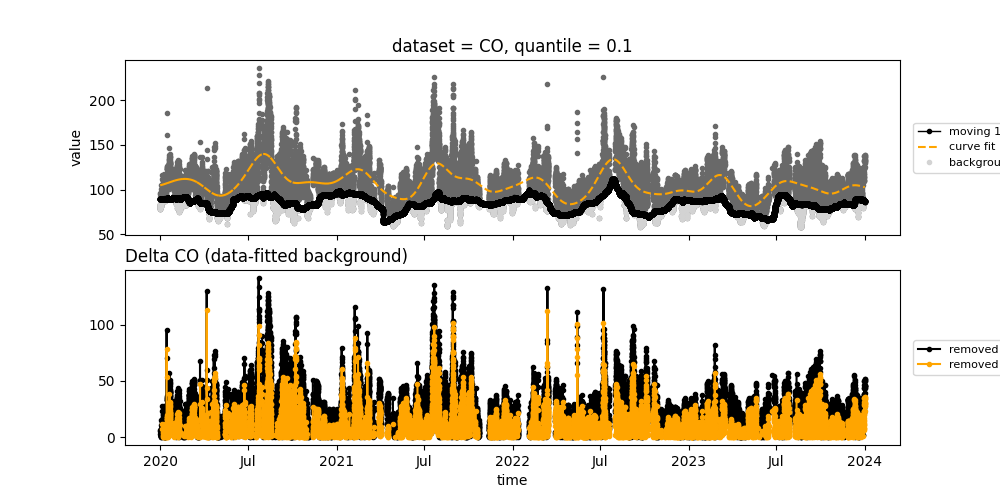

In [7]:
## Plot and get  backgrounds for CO, using different background methods
dataset_str = "CO"
delta_co_quant,  delta_co_curvefit = plot_background(dataset_str,t1, t2,save_fig=True)

### Check GFAS-derived CO data (footprint-weighted)

In [ ]:
# ## Read in GFAS-derived flexpart CO: 
# co_flexpart_gfas = xr.open_dataset('../data/level3/flexpart/weighted_co_ts_values_2020-2023.nc')
# co_flexpart_edgar = xr.open_dataset('../data/level3/flexpart/weighted_co_EDGAR_TOTALS_ts_values_2020_2022.nc') #EDGAR totals
# co_flexpart_edgar_awb = xr.open_dataset('../data/level3/flexpart/weighted_co_EDGAR_AWB_ts_values_2020_2022.nc') #EDGAR totals
# #co_flexpart_edgar_no_agri = xr.open_dataset('../data/level3/flexpart/weighted_co_EDGAR_total_without_agri_ts_values_2975m_2020-2022.nc') # not sure...

# #bc_flexpart = xr.open_dataset('H:/KADI/Analyses_output/Flexpart/weighted_bc_ts_values_2023-01.nc')

# co_flexpart_gfas = co_flexpart_gfas.rename({'release_time':'time'})

## Read in GFAS-derived flexpart CO:
co_flexpart_gfas = xr.open_dataset(
    data_path + "level3/flexpart/weighted_co_ts_values_2020-2023.nc"
)
co_flexpart_edgar = xr.open_dataset(
    data_path + "level3/flexpart/weighted_co_EDGAR_ALL_ts_values_2020_2024.nc"
)  # EDGAR totals
# co_flexpart_edgar_awb = xr.open_dataset(
#     data_path + "level3/flexpart/weighted_co_EDGAR_AWB_ts_values_2020_2022.nc"
# )  # EDGAR totals
# # co_flexpart_edgar_no_agri = xr.open_dataset(data_path +'level3/flexpart/weighted_co_EDGAR_total_without_agri_ts_values_2975m_2020-2022.nc') # not sure...

# bc_flexpart = xr.open_dataset('H:/KADI/Analyses_output/Flexpart/weighted_bc_ts_values_2023-01.nc')

co_flexpart_edgar_3h = xr.open_dataset(
    data_path + "level3/flexpart/weighted_co_EDGAR_ALL_ts_values_3h_2020_2023.nc"
)  # EDGAR totals, 3-hourly
# process to 3-hourly ts (if not done yet in flexpart folding)
co_flexpart_edgar_3h = process_data.flexpart_to_3hourly(co_flexpart_edgar_3h)

co_flexpart_gfas = co_flexpart_gfas.rename({"release_time": "time"})


# Same but for full domain
co_flexpart_edgar_full_domain = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ts_full_domain/weighted_co_EDGAR_ALL_ts_values_2020_2024.nc"
)

co_flexpart_gfas_full_domain = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ts_full_domain/weighted_co_GFAS_ALL_ts_values_2975m_2020-2021.nc"
)
co_flexpart_gfas_full_domain = co_flexpart_gfas_full_domain.rename({"release_time": "time"})


In [ ]:
## Diurnal flexpart variability
z_sel = 2975  # 2975m or 3678m
plt.figure()
co_flexpart_edgar_3h.groupby("time.hour").mean()['co_contribution'].sel(release_height=z_sel).plot(color="C1",label=str(z_sel))
# 3678 only contains 1 year so far
#co_flexpart_edgar_3h.groupby("time.hour").mean()['co_contribution'].sel(release_height=3678).plot(color="C2",label=str(3678))
#plt.legend()
plt.title("Diurnal cycle of CO contribution from EDGAR (3h)")
plt.show()

In [ ]:
## Check nested vs. full domain (EDGAR)

plt.subplots(1, 1, figsize=(13, 4))
co_flexpart_edgar['co_contribution'].isel(release_height=0).plot(label='EDGAR')
co_flexpart_edgar_full_domain['co_contribution'].isel(release_height=0).plot(label='EDGAR full domain',ls='--') #
plt.legend()    
fig_name = f"co_contributions_flexpart_edgar_full_vs_nested"
plt.savefig(
f"{dir_save}flexpart/{fig_name}.png", dpi=300, bbox_inches='tight'
    )
plt.show()

In [ ]:
## Check nested vs. full domain (fire GFAS)

plt.subplots(1, 1, figsize=(13, 4))
co_flexpart_gfas['co_contribution'].isel(release_height=0).plot(label='GFAS')
co_flexpart_gfas_full_domain['co_contribution'].plot(label='GFAS full domain',ls='--') #.isel(release_height=0)
plt.legend()    
fig_name = f"co_contributions_flexpart_gfas_full_vs_nested"
plt.savefig(
f"{dir_save}flexpart/{fig_name}.png", dpi=300, bbox_inches='tight'
    )
plt.show()

In [ ]:
edgar_full = co_flexpart_edgar_full_domain['co_contribution'].isel(release_height=0)
edgar_africa = co_flexpart_edgar['co_contribution'].isel(release_height=0)
gfas_full = co_flexpart_gfas_full_domain['co_contribution']#.isel(release_height=0)
gfas_africa = co_flexpart_gfas['co_contribution'].isel(release_height=0)

plt.figure()
((edgar_full-edgar_africa)/edgar_full*100).plot(label='EDGAR non-African vs. African emissions')
((gfas_full - gfas_africa)/gfas_full*100).plot(label='GFAS non-African vs. African emissions')

plt.title("relative difference compared to full domain (%)")
plt.ylabel("rel. diff. (%)")

plt.legend()
fig_name = f"co_contributions_flexpart_gfas_edgar_full_vs_nested_percent"
plt.savefig(
f"{dir_save}flexpart/{fig_name}.png", dpi=300, bbox_inches='tight'
    )
plt.show()

In [ ]:
#### Read in the background CO data derived from CAMS
co_bg = xr.open_dataset('../data/level3/flexpart/MKN_co_BC_CAMS_EAC4_2020_2023.nc')
co_bg_daily = co_bg['CO_bg'].resample(time='1D').mean()

## Adding natural and Anthropogenic CO from EDGAR
co_all = co_bg_daily + co_flexpart_gfas['co_contribution'] + co_flexpart_edgar['co_contribution'] 
# remove agiruclture to avoid double counting: 
#co_all_removed_agri = co_bg_daily + co_flexpart_gfas['co_contribution'] + co_flexpart_edgar['co_contribution'] - co_flexpart_edgar_awb['co_contribution']

In [ ]:
# plt.subplots(figsize=(15,5))
# #delta_co_curvefit.plot()
# # use noaa-background or quantiles (delta_co_quant)

# bc_flexpart['bc_contribution'].plot(label='BC contribution from fires (flexpart)')
# co_flexpart.sel(release_time=slice('2023-01-01', '2023-01-31'))['co_contribution'].plot(label='CO contribution from fires (flexpart)',ls='--')
# plt.legend()
# plt.show()

In [ ]:
## Compare 
plt.subplots(figsize=(15,5))
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)

delta_co_curvefit.where(delta_co_curvefit > 0).resample(time='1D').mean().plot(label='CO daily data above background (NOAA curve fit)') # Only use data ABOVE the curvefit/background??

for z in co_flexpart_gfas.release_height.values:
    co_flexpart_gfas['co_contribution'].sel(release_height=z).plot(label=f'CO contribution from fires (flexpart) at {z}m')
#co_flexpart_edgar['co_contribution'].plot(label='anthropogenic CO contribution (EDGAR TOTALS 2975m)',ls='--')
plt.legend()
plt.show()

In [ ]:
### Full CO data (not above mean) with flexpart files with added CAMS-derived background: 
species = 'CO'

obs = ds_all.sel(dataset=species, time=slice(t1, t2))['value'].resample(time='1D').mean()

## Compare 
fig, axs = plt.subplots(2,1,figsize=(15,5))
obs.plot(label='CO daily measured data',ax=axs[0]) # Only use data ABOVE the curvefit/background??

for z in co_flexpart_gfas.release_height.values:
#z = co_flexpart.release_height.values[0]
    (co_flexpart_gfas['co_contribution'] + co_bg_daily).sel(release_height=z).plot(label=f'CO contribution from fires (flexpart) at {z}m',ax=axs[0])
    
    co_diff = obs - co_all_removed_agri.sel(release_height=z)
    mean_diff = co_diff.mean(dim='time').values
    co_diff.plot(label=f'CO difference (measured - model) at {z}m (mean diff: {mean_diff:.2f})',ax=axs[1])
plt.legend()
plt.show()

In [ ]:
### Full CO data  with flexpart files with added CAMS-derived background: 
mw_roll = 10
frac_mw_min = 0.5 #frac_mw_min Fraction of mw that is accepted as min number in a moving window (e.g. =0.5, for mw=10days it would accept 5days)
species = 'CO'
obs = ds_all.sel(dataset=species, time=slice(t1, t2))['value'].resample(time='1D').mean()

fig,axs = plt.subplots(2,1,figsize=(12,10),sharex=True)

ax0 = axs[0]
ax1 = axs[1]

z = co_flexpart_gfas.release_height.values[1] # define which level to use (2975 or 3678m)

co_bg_daily.sel(release_height=z).plot(label=f'CO background contribution (flexpart+CAMS)',ax=ax0,color='darkgrey')
obs.plot(label='CO daily measured data',ax=ax0,color='tab:blue') # Only use data ABOVE the curvefit/background??
(co_flexpart_gfas['co_contribution'] + co_bg_daily).sel(release_height=z).plot(label=f'CO contribution from fires (flexpart*GFAS+ background)',ax=ax0,color='tab:red')

co_all.sel(release_height=z).plot(label=f'Total CO contribution (fires+anthropogenic)',ax=ax0,color='grey', ls='--')
co_all_removed_agri.sel(release_height=z).plot(label=f'corrected total CO contribution (fires+anthropogenic-agriculture_burning)',ax=ax0,color='k', ls='--')

ax0.legend()
ax0.set_title('')
ax0.set_title(f'CO measurements and flexpart-derived CO contribution from fires at Mt. Kenya ({z}m)',loc='left')

# second plot
co_diff = obs - co_all_removed_agri.sel(release_height=z)

#co_diff = obs - co_all_2975

#co_diff.plot(ax=ax,label=f'obs - sim')
co_diff_rolled = co_diff.rolling(time=mw_roll,center=True,min_periods=mw_roll*frac_mw_min).mean()
co_diff_rolled.plot(ax=ax1,label=f'obs-sim ({mw_roll}days smoothed)',color='darkgrey')

ax1.fill_between(co_diff_rolled.time, co_diff_rolled, 0, where=co_diff_rolled>=0, facecolor='tab:red', interpolate=True, alpha=0.3)
ax1.fill_between(co_diff_rolled.time, co_diff_rolled, 0, where=co_diff_rolled<=0, facecolor='tab:blue', interpolate=True, alpha=0.3)

#ax1.set_ylim([-60,100])
# zero line
ax1.axhline(0,ls='-',color='grey')
ax1.set_title('')
ax1.set_title(f'CO difference between observed and simulated',loc='left')

ax1.legend()

for ax in axs:
    ax.set_xlabel('')
    ax.set_ylabel('CO (ppb)')

fig.subplots_adjust(
    hspace=0.2, wspace=0.2, left=0.1, right=1, bottom=0.5, top=0.9
)  
plt.show()  

In [ ]:
### Check the newly read in CO data from EDGAR derived from emiproc
### CHECK EDGAR ALL (PRELIMINARY)
co_flexpart_edgar_emiproc  = xr.open_dataset(
    data_path + "level3/flexpart/weighted_co_EDGAR_ALL_ts_values_2020_2024.nc"
)  # EDGAR totals
co_all_emiproc = (
    co_bg_daily
    + co_flexpart_gfas["co_contribution"]
    + co_flexpart_edgar_emiproc["co_contribution"]
)

In [ ]:
plt.figure()
for var in co_flexpart_edgar_emiproc.data_vars:
    if var == 'co_contribution':
        continue
    (co_flexpart_edgar_emiproc[var]).sel(
        release_height=2975
    ).plot(label=var)
plt.legend()
plt.show()

In [ ]:
## The new emicproc-derived folded time series is not at all the same!!! 
# WHATS wrong? Maybe something when converting from emission to flux in the folding??
plt.figure()
co_all.sel(
        release_height=2975
    ).plot(label='EDGAR initial fluxes')
co_all_emiproc.sel(
        release_height=2975
    ).plot(label='EDGAR ALL emissions')
plt.legend()
plt.show()

In [ ]:
plt.figure()
co_flexpart_edgar['co_contribution'].sel(
        release_height=2975
    ).plot(label='EDGAR initial fluxes')
(co_flexpart_edgar_emiproc['co_contribution']*1000).sel(
        release_height=2975
    ).plot(label='EDGAR ALL emissions',ls=':')
plt.legend()
plt.show()

In [ ]:
# Difference between observed and simulated CO
fig, axs = plt.subplots(1,2,figsize=(15,5))
co_diff = obs - (co_flexpart_gfas['co_contribution'] + co_bg_daily).sel(release_height=co_flexpart.release_height.values[0])
co_diff2 = obs - (co_flexpart_gfas['co_contribution'] + co_bg_daily).sel(release_height=co_flexpart.release_height.values[-1])
co_diff.plot(ax=axs[0],label=f'obs - sim')
co_diff.groupby('time.month').mean().plot(ax=axs[1])
plt.legend()
plt.show()

In [ ]:
plt.subplots(figsize=(15,5))
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)

delta_co_quant.where(delta_co_quant > 0).resample(time='1D').mean().plot(label='CO data above background (10th-quantile)') # Only use data ABOVE the curvefit/background??

for z in co_flexpart.release_height.values:
    co_flexpart['co_contribution'].sel(release_height=z).plot(ls='--',label=f'CO contribution from fires (flexpart) at {z}m')
plt.legend()
plt.show()

In [ ]:
# check day vs night data

mknlat, mknlon, mknalt = get_station_coords("MKN")  # Mt. Kenya station coordinates
sun_mkn = Sun(mknlat, mknlon)
# today_sr = sun.get_sunrise_time()
# today_ss = sun.get_sunset_time()
# print('Today at MKN the sun raised at {} and get down at {} UTC'.
#       format(today_sr.strftime('%H:%M'), today_ss.strftime('%H:%M')))


In [ ]:
sunrise_times = [sun_mkn.get_sunrise_time(to_datetime(t)) for t in delta_co_curvefit.time.values]
# transform times to decimal times
sunrise_times_decimal = [t.hour + t.minute/60 for t in sunrise_times]

sunset_times = [sun_mkn.get_sunset_time(to_datetime(t)) for t in delta_co_curvefit.time.values]
# transform times to decimal times
sunset_times_decimal = [t.hour + t.minute/60 for t in sunset_times]

In [ ]:
# make a pandas dataframe with sunrise and sunset times for each timestep
# set time as index
df = pd.DataFrame(index=pd.DatetimeIndex(pd.to_datetime(delta_co_curvefit.time.values)))
df['time'] = [t.time() for t in df.index]
df['time_sunrise'] = [t.time() for t in sunrise_times]
df['time_sunset'] = [t.time() for t in sunset_times]
df['is_day'] = (df['time'] > df['time_sunrise']) & (df['time'] < df['time_sunset'])
df

In [ ]:
dates_day = df.index.where(df['is_day']).dropna().values
dates_night = df.index.where(df['is_day']==False).dropna().values
day_data = delta_co_curvefit.where(delta_co_curvefit['time'].isin(dates_day))
night_data = delta_co_curvefit.where(delta_co_curvefit['time'].isin(dates_day)==False)

In [ ]:
plt.subplots(figsize=(15,5))
day_data.where(day_data > 0).plot(label='CO during day above background (NOAA curve fit)')
night_data.where(night_data > 0).plot(label='CO during night above background (NOAA curve fit)') # Only use data ABOVE the curvefit/background??
co_flexpart['co_contribution'].sel(release_height=z).plot(label='CO contribution from fires (flexpart)')
plt.legend()
plt.show()

In [ ]:
# # scatterplot for night data only
# import seaborn as sns
# import scipy 
# night_data = delta_co_curvefit.where(delta_co_curvefit['time'].isin(dates_day)==False,drop=True)

# data_to_plot = night_data
# #data_to_plot = delta_co_curvefit

# x = co_flexpart['co_contribution'].resample(release_time='D').mean().values
# y = data_to_plot.where(data_to_plot>0).resample(time='D').mean().values
# plt.figure()
# p = sns.regplot(x=x,y=y)
# plt.show()

# #calculate slope and intercept of regression equation
# slope, intercept, r, p, sterr = scipy.stats.linregress(x=p.get_lines()[0].get_xdata(),
#                                                        y=p.get_lines()[0].get_ydata())

# print(f"Regression equation: y = {slope:.2f}x + {intercept:.2f}, r = {r:.2f}, p = {p:.2f}, sterr = {sterr:.2f}")

In [ ]:
# # scatter plot for July 2021
# night_data = delta_co_curvefit.where(delta_co_curvefit['time'].isin(dates_day)==False,drop=True)

# data_to_plot = night_data
# data_to_plot = delta_co_curvefit.sel(time=slice('2021-07-15','2021-07-31'))

# x = co_flexpart['co_contribution'].sel(release_time=slice('2021-07-15','2021-07-31')).resample(release_time='D').mean().values
# y = data_to_plot.where(data_to_plot>0).resample(time='D').mean().values
# plt.figure()
# p = sns.regplot(x=x,y=y)
# plt.show()

# #calculate slope and intercept of regression equation
# slope, intercept, r, p, sterr = scipy.stats.linregress(x=p.get_lines()[0].get_xdata(),
#                                                        y=p.get_lines()[0].get_ydata())

# print(f"Regression equation: y = {slope:.2f}x + {intercept:.2f}, r = {r:.2f}, p = {p:.2f}, sterr = {sterr:.2f}")

In [ ]:
# ## Compare CO and CO deltas (removed background)

# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# sampling = '1D'
# # x= delta_co2_quant.where(delta_co2_quant > 0).resample(time=sampling).mean()
# # y= delta_co_quant.where(delta_co_quant > 0).resample(time=sampling).mean()
# # compare noaa backgrounds:
# x= delta_co2_curvefit.where(delta_co2_curvefit > 0)
# y= delta_co_curvefit.where(delta_co_curvefit > 0)

# #compare CO2-MBL background with CO percentile background:
# # x= delta_co2_mbl
# # y= delta_co.sel(time=slice(x.time[0],x.time[-1]))

# months = x.time.dt.month

# # Define a colormap for months
# colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months
# colors = colmap(np.linspace(0, 1, 12))

# fig, ax = plt.subplots(layout='constrained')
# scatter = ax.scatter(x, y, c=months, cmap=colmap, alpha=1,s=3)
# ## add line fits:
# # Iterate over unique months and fit a line for each month
# for month, c in zip(range(1, 13), colors):
#     # Filter data for the current month
#     x_month = x.where(x.time.dt.month == month, drop=True)
#     y_month = y.where(y.time.dt.month == month, drop=True)

#     # data may contain some nans, remove them to be able to make a fit
#     y_month_non_nan = y_month.dropna(dim="time")
#     x_month_non_nan = x_month.sel(time=y_month_non_nan.time.values, drop=True) #select corresponding data
#     # other way around
#     x_month_non_nan = x_month_non_nan.dropna(dim="time")
#     y_month_non_nan = y_month.sel(time=x_month_non_nan.time.values, drop=True) #select corresponding data

#     if len(x_month) > 1:
#         # Fit a linear regression model
#         model = LinearRegression()
#         model.fit(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)

#         # Predictions
#         x_pred = np.linspace(
#             x.min(), x.max(), 2
#         )  # create x-values for which to predict y-values
#         y_pred = model.predict(x_pred.reshape(-1, 1))

#         # Plot the line fit for the current month
#         r2 = model.score(x_month_non_nan.values.reshape(-1, 1), y_month_non_nan.values)
#         slope = model.coef_[0]
#         month_str = dt.datetime.strptime(str(month), "%m").strftime("%b")
#         ax.plot(
#             x_pred, y_pred, color=c, label=f"{month_str} ({r2:.2f}, {slope:.2f})"
#         ) 
#     else:
#         print(f"no fit for month {month}")
# ax.set_ylabel(f"Delta CO (ppb)")
# ax.set_xlabel("Delta CO2 (ppm)")

# # general figure properties
# plt.setp(ax, box_aspect=1)  # get quadratic plots
# legend1 = ax.legend(
#     #*scatter.legend_elements(), 
#     loc="upper left", title="Months (R2, slope)",
#     bbox_to_anchor=(1,1)
# )
# ax.add_artist(legend1)
# plt.autoscale(tight=True)
# plt.show()


# fig_name = f'scatter_deltaCO_deltaCO2_{sampling}'
# #fig_name = 'scatter_deltaCO_deltaCO2_NOAAbckgr'
# plt.savefig(f"{dir_save}background/{fig_name}.png", 
#     bbox_extra_artists=(legend1,), bbox_inches='tight')


In [ ]:
# df = x.to_dataframe(name='delta_co2')
# df = pd.concat([df,y.to_dataframe(name='delta_co')])
# df['month'] = df.index.month
# #df['season'] = df.index.season
 
# import seaborn as sns
# plt.figure()
# sns.scatterplot(df,x='delta_co2',y='delta_co',hue='month',legend='full')
# plt.show()

In [ ]:
# # same with seaborn (but without regression line)
# df = x.to_dataframe(name='delta_co2')
# df = pd.concat([df,y.to_dataframe(name='delta_co')])
# df['month'] = df.index.month
# #df['season'] = df.index.season
 
# import seaborn as sns
# plt.figure()
# sns.scatterplot(df,x='delta_co2',y='delta_co',hue='month',legend='full')
# plt.show()

### Check BC data (folded with flexpart)

In [8]:
#black carbon data: 

# species to plot
species_aer = 'black_carbon'

# aerosol data (with fire events/outliers included or not)
# Define which wavelenght to use for black carbon data
lambda_bc = 880 # wavelength for black carbon
aer_sel = ds_aerosols.sel(lambda_abs=lambda_bc)[species_aer] #/1000 #convert to µg/m³
aer_sel_rem_out = ds_aerosols_rem_out.sel(lambda_abs=lambda_bc)[species_aer] #/1000 #convert to µg/m³



In [16]:
## Read in GFAS-derived flexpart BC: 
bc_flexpart = xr.open_dataset('../data/level3/flexpart/weighted_bc_ts_values_2020-2023.nc')

In [ ]:
## Read in flexpart bc
## Directly convert folded Black carbon from kg/m³ to µg/m³

bc_flexpart_gfas = xr.open_dataset(
    data_path + "level3/flexpart/weighted_bc_ts_values_2020-2023.nc"
) * 1e9  # convert from kg/m³ to µg/m³

bc_flexpart_edgar = xr.open_dataset(
    data_path + "level3/flexpart/weighted_bc_EDGAR_ALL_ts_values_2020_2024.nc"
) * 1e9  # convert from kg/m³ to µg/m³


# Same but for full domain
# bc_flexpart_gfas_full_domain = xr.open_dataset(
#      data_path + "level3/flexpart/weighted_ts_full_domain/weighted_bc_GFAS_ALL_ts_values_2975m_2020-2023.nc") # NOT RUN YET
bc_flexpart_edgar_full_domain = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ts_full_domain/weighted_bc_EDGAR_ALL_ts_values_2020_2024.nc"
)

# rename time for GFAS
bc_flexpart_gfas = bc_flexpart_gfas.rename({"release_time": "time"})
# NOT RUN YET!!!
#bc_flexpart_gfas_full_domain = bc_flexpart_gfas_full_domain.rename({"release_time": "time"})
# so far, the gfas full domain was only run for one release level. For consistency, add the release_height coordinate: 
#bc_flexpart_gfas_full_domain = cbc_flexpart_gfas_full_domain.expand_dims({'release_height':co_flexpart_gfas.coords["release_height"]})

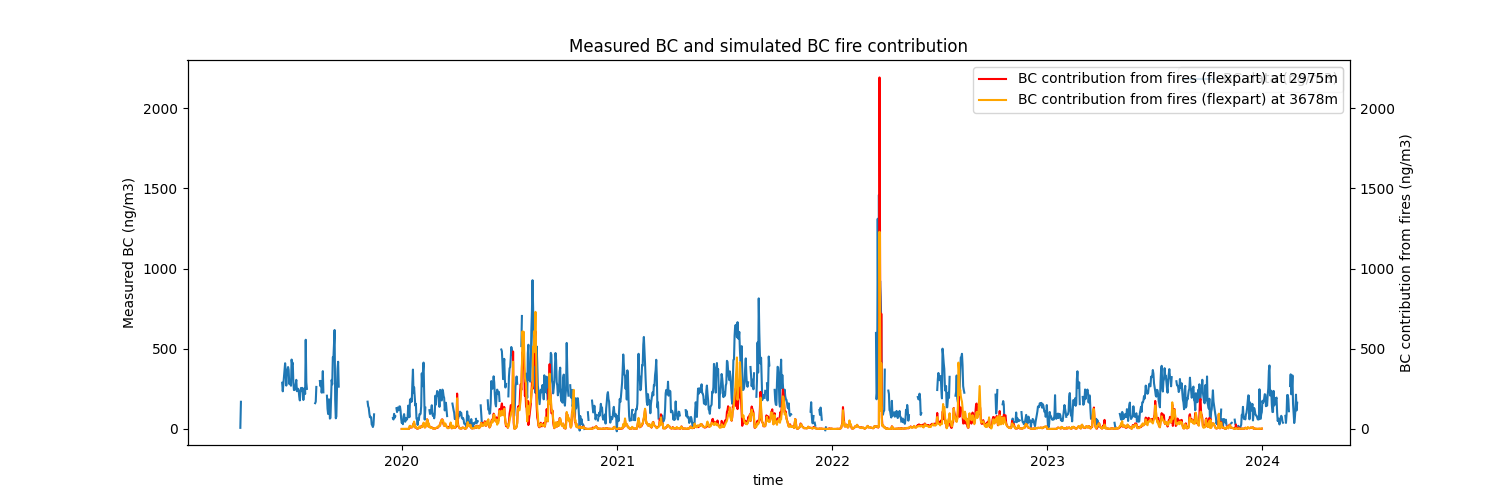

In [17]:
## Compare 
fig, ax = plt.subplots(figsize=(15,5),sharex=True)
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)

aer_sel.resample(time='1D').mean().plot(ax=ax,label='BC data (ng/m3)') 

# 
ax2 = ax.twinx()
colors = ['red','orange']
for i,z in enumerate(bc_flexpart.release_height.values):
    ((bc_flexpart['bc_contribution'])*1e12).sel(release_height=z).plot(label=f'BC contribution from fires (flexpart) at {z}m',ax=ax2,color=colors[i]) # convert from kg/m3 to ng/m3 
ax.set_ylabel('Measured BC (ng/m3)')
ax2.set_ylabel('BC contribution from fires (ng/m3)')
ax.set_title('')
ax2.set_title('')
for iax in [ax,ax2]:
    iax.set_ylim([-100,2300])
plt.title("Measured BC and simulated BC fire contribution")
ax.legend()
ax2.legend()
plt.show()



In [10]:
#### Read in the background BC data derived from CAMS
bc_bg1 = xr.open_dataset(
    data_path + "level3/flexpart/MKN_aermr09_BC_CAMS_EAC4_2020_2023.nc"
)['aermr09_bg'] 
bc_bg2 = xr.open_dataset(
    data_path + "level3/flexpart/MKN_aermr10_BC_CAMS_EAC4_2020_2023.nc"
)['aermr10_bg'] 
bc_bg = bc_bg1 + bc_bg2  # combine the two CAMS BC datasets
## add up hydrophilic and hydrophobic
# Note: CAMS data is in kg/kg, so I need to convert it to µg/m³

bc_bg_daily = bc_bg.resample(time="1D").mean()


# ## Adding Anthropogenic from EDGAR
bc_all = (
    bc_bg_daily
    + bc_flexpart["bc_contribution"] 
)  

In [11]:
## Convert background Black carbon MMR to VMR
# determine time series of air density
# rho_d = p/(T*R) # in kg/m³

# get CAMS EAC4 data for temperature#
# Load the selected cams data at Mt. Kenya
cams_best_grid = xr.open_dataset(f"{data_path}/level3/cams/cams_best_grid_merged_MKN.nc") #selection where 2 invgg periods (different resolution) were merged

## Remove cams products that I don't want to plot
cams_best_grid = cams_best_grid.drop_sel(dataset=["co2_egg4","ch4_egg4"])
## Select the same grid as for CO -EAC4 data
eac_lat, eac_lon, eac_lev = [
    cams_best_grid.sel(dataset="co_eac4")[var].values # use the same pressure level as for CO
    for var in ["latitude", "longitude", "level"]
]
cams_eac4 = xr.open_dataset(f"/project/leob/GAW/Kenya/data/CAMS/EAC4/cams_eac4_2003_2023_MKN.nc")
cams_eac4_sel = cams_eac4.sel(latitude=eac_lat,longitude=eac_lon, level=eac_lev,drop=True)

R_dry_air = 287.052874 # J/kg/K
rho_d = eac_lev * 100 / (cams_eac4_sel['t'] * R_dry_air)# in kg/m³
bc_bg = bc_bg * rho_d * 1e9 # in kg/m³ - >convert to µg/m³ with *1e-9

In [ ]:
# NOT WORKING YET!!
plt.figure(figsize=(10, 4))
aer_sel.resample(time='1D').mean().plot(ls="-",label='observations')
bc_bg.isel(release_height=0).resample(time="1D").mean().plot(c='grey',label='CAMS background')
plt.ylabel("Black carbon (µg/m³)")
plt.legend()
plt.show()

### Check CH4 data folded with flexpart

In [ ]:
## Read in GFAS-derived flexpart ch4

data_path = "../data/"
## Read in GFAS-derived flexpart ch4
ch4_flexpart_gfas = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ch4_ts_values_GFAS_2020-2023.nc"
)
ch4_flexpart_edgar = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ch4_EDGAR_ALL_ts_values_2020_2024.nc"
)
ch4_flexpart_edgar_3h = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ch4_EDGAR_ALL_ts_values_3h_2020_2023.nc"
)  # EDGAR totals, 3-hourly

ch4_flexpart_wetcharts = xr.open_dataset(data_path + "level3/flexpart/weighted_ch4_WetCHARTs_wetlands_ts_values_2020_2024.nc")
ch4_flexpart_wetcharts_3h = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ch4_WetCHARTs_wetlands_ts_values_3h_2020_2023.nc"
)  # EDGAR totals, 3-hourly

ch4_flexpart_gfas = ch4_flexpart_gfas.rename({"release_time": "time"})
# define release height
z_sel = 2975 # 2975m or 3678m 

# Same but for full domain
ch4_flexpart_edgar_full_domain = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ts_full_domain/weighted_ch4_EDGAR_ALL_ts_values_2020_2024.nc"
)
ch4_flexpart_wetcharts_full_domain = xr.open_dataset(data_path + "level3/flexpart/weighted_ts_full_domain/weighted_ch4_WetCHARTs_wetlands_ts_values_2020_2024.nc")


In [ ]:
#### Read in the background Ch4 data derived from CAMS
ch4_bg = xr.open_dataset('../data/level3/flexpart/MKN_ch4_BC_CAMS_GHGINV_v23r1_2020_2023.nc')
ch4_bg_daily = ch4_bg['CH4_bg'].resample(time='1D').mean()
ch4_bg = ch4_bg["CH4_bg"]

## Combination of flexpart derived CO with background: 
ch4_from_fires = ch4_flexpart_gfas['ch4_contribution'] # daily means

# ## Adding Anthropogenic from EDGAR# ## Adding Anthropogenic from EDGAR
ch4_all = (
    ch4_bg_daily
    + ch4_flexpart_gfas["ch4_contribution"] 
    + ch4_flexpart_edgar["ch4_contribution"]
    + ch4_flexpart_wetcharts["ch4_contribution"]
)  # edgar and wetcharts not yet done for 3678mz

# ## Adding Anthropogenic from EDGAR
ch4_all_3h = (
    ch4_bg
    #+ ch4_flexpart_gfas_3h["ch4_contribution"]  # not run yet!!
    + ch4_flexpart_edgar_3h["ch4_contribution"]
    + ch4_flexpart_wetcharts_3h["ch4_contribution"]
)  # edgar and wetcharts not yet done for 3678mz

In [ ]:
## Compare with background
mw_roll = 10
frac_mw_min = 0.5 #frac_mw_min Fraction of mw that is accepted as min number in a moving window (e.g. =0.5, for mw=10days it would accept 5days)

fig,axs = plt.subplots(2,1,figsize=(12,10),sharex=True)
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)
ax0 = axs[0]
ax1 = axs[1]

obs = ds_all.sel(dataset='CH4', time=slice(t1, t2))['value'].resample(time='1D').mean()
obs.plot(label='CH4 daily data',ax=ax0) # Only use data ABOVE the curvefit/background??

(obs-obs).plot(ls='',marker='',ax=ax1) # to keep color cycle correct

for z in ch4_flexpart_gfas.release_height.values:
    (ch4_bg_daily).sel(release_height=z).plot(label=f'CH4 background (flexpart/CAMS) at {z}m',ax=ax0)
    ax0.legend()

    # second plot: difference between observed and background
    ch4_diff = obs - ch4_bg_daily.sel(release_height=z)

    #ch4_diff = obs - ch4_all_2975

    #ch4_diff.plot(ax=ax,label=f'obs - sim')
    ch4_diff_rolled = ch4_diff.rolling(time=mw_roll,center=True,min_periods=mw_roll*frac_mw_min).mean()
    ch4_diff_rolled.plot(ax=ax1,label=f'obs-sim ({mw_roll}days smoothed) at {z}m-model-height')

    #ax.fill_between(ch4_diff_rolled.time, ch4_diff_rolled, 0, where=ch4_diff_rolled>=0, facecolor='tab:red', interpolate=True, alpha=0.3)
    #ax.fill_between(ch4_diff_rolled.time, ch4_diff_rolled, 0, where=ch4_diff_rolled<=0, facecolor='tab:blue', interpolate=True, alpha=0.3)
    

    #ax.set_ylim([-60,100])
    # zero line
    ax1.axhline(0,ls='-',color='grey')
    ax1.set_title('')
    ax1.set_title(f"Observations - background ")
    ax1.legend()

plt.legend()
plt.show()


In [ ]:
## Compare above background
z = 2975
plt.subplots(figsize=(15,5))
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)

(ds_all.sel(dataset='CH4', time=slice(t1, t2))['value'].resample(time='1D').mean() - ch4_bg_daily.sel(release_height=z)).plot(label='(CH4 daily data)-background ') # Only use data ABOVE the curvefit/background??

(ch4_flexpart_gfas['ch4_contribution']).sel(release_height=z).plot(label=f'CH4 contribution from fires (flexpart) at {z}m')  
#((ch4_flexpart_gfas['ch4_contribution'])).plot(marker='.',label=f'CH4 contribution from fires (flexpart) at {z}m') 


(ch4_flexpart_wetcharts['ch4_contribution'].sel(release_height=z)).plot(label="wetcharts") 
ch4_flexpart_edgar['ch4_contribution'].sel(release_height=z).plot(label="EDGAR")
ch4_flexpart_edgar_full_domain['ch4_contribution'].sel(release_height=z).plot(label="EDGAR full domain")


plt.legend()
plt.title("above background")
plt.show()


In [ ]:
# compare different heights
plt.subplots(figsize=(15,5))
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)

ds_all.sel(dataset='CH4', time=slice(t1, t2))['value'].resample(time='1D').mean().plot(label='CH4 daily data') # Only use data ABOVE the curvefit/background??

for z in ch4_flexpart_gfas.release_height.values:
    ((ch4_from_fires+ ch4_bg_daily)).sel(release_height=z).plot(label=f'CH4 contribution from fires at {z}m')  
#((ch4_flexpart_gfas['ch4_contribution'])).plot(marker='.',label=f'CH4 contribution from fires (flexpart) at {z}m') 

    (ch4_flexpart_wetcharts['ch4_contribution'].sel(release_height=z)  + ch4_bg_daily.sel(release_height=z) ).plot(label=f"wetcharts at {z}m")
    ((ch4_flexpart_edgar['ch4_contribution']+ ch4_bg_daily)).sel(release_height=z).plot(label=f'CH4 contribution from Edgar at {z}m')  
plt.legend()
plt.show()


In [ ]:
## Stack contrbutions above background at selected height
fig, ax = plt.subplots(figsize=(15,5))
#delta_co_curvefit.plot()
# use noaa-background or quantiles (delta_co_quant)
z =2975 

ds_all.sel(dataset='CH4', time=slice(t1, t2))['value'].resample(time='1D').mean().plot(label='CH4 daily data') # Only use data ABOVE the curvefit/background??

bgr = ch4_bg_daily.sel(release_height=z)
anthro = ch4_flexpart_edgar['ch4_contribution'].sel(release_height=z,time=slice('2020-01-01','2023-12-31'))
gfas = (ch4_flexpart_gfas['ch4_contribution']).sel(release_height=z)
wetland = ch4_flexpart_wetcharts['ch4_contribution'].sel(release_height=z,time=slice('2020-01-01','2023-12-31'))

bgr.plot(label=f'CH4 background contribution (flexpart with CAMS)',color='darkgrey')
baseline = 1820
ax.fill_between(bgr.time, bgr, baseline, facecolor='darkgrey', interpolate=True, alpha=0.3)

baseline = bgr
ax.fill_between(anthro.time, anthro+baseline, baseline, facecolor='k', interpolate=True, alpha=0.6)

baseline = anthro+baseline
ax.fill_between(gfas.time, gfas+baseline, baseline, facecolor='tab:red', interpolate=True, alpha=0.3)  

baseline = gfas+baseline
ax.fill_between(wetland.time, wetland+baseline.sel(time=wetland.time), baseline.sel(time=wetland.time), facecolor='tab:green', interpolate=True, alpha=0.3)

#(ch4_flexpart_wetcharts['ch4_contribution'] + ch4_bg_daily.sel(release_height=2975)).plot(label="wetcharts")
plt.legend()
plt.show()

In [ ]:
### Full CH4 data  with flexpart files with added CAMS-derived background: 

species = 'CH4'
obs = ds_all.sel(dataset=species, time=slice(t1, t2))['value'].resample(time='1D').mean()

mw_roll = 10
frac_mw_min = 0.5 #frac_mw_min Fraction of mw that is accepted as min number in a moving window (e.g. =0.5, for mw=10days it would accept 5days)


fig,axs = plt.subplots(3,1,figsize=(12,10),sharex=True)

ax0 = axs[0]
ax1 = axs[1]
ax2 = axs[2]

ch4_bg_daily.sel(release_height=z_sel).plot(label=f'CH4 background contribution (flexpart+CAMS)',ax=ax0,color='darkgrey')
obs.plot(label='CH4 daily measured data',ax=ax0,color='tab:blue') # Only use data ABOVE the curvefit/background??

#natural sources:
(ch4_bg_daily +  ch4_flexpart_gfas['ch4_contribution'] + ch4_flexpart_wetcharts['ch4_contribution']).sel(release_height=z_sel).plot(label=f'Natural CH4 (fires+wetland)',ax=ax0,color='tab:green', lw = 0.8)

# anthropogenic:
(ch4_flexpart_edgar['ch4_contribution'].sel(release_height=z_sel)  + ch4_bg_daily.sel(release_height=z_sel)).plot(label=f'Anthropogenic CH4',ax=ax0,color='k', lw = 0.8)

#ch4_all.sel(release_height=z_sel).plot(label=f'Total CH4 contribution (anthropogenic+fires+wetland)',ax=ax0,color='tab:red', ls='--', lw = 0.5)

ax0.legend()
ax0.set_title('')
ax0.set_title(f'CH4 measurements and flexpart-derived CH4 contribution from fires at Mt. Kenya ({z}m)',loc='left')

# second plot: difference between observed and background
#ch4_diff = obs - ch4_from_fires.sel(release_height=z)
ch4_diff = obs - ch4_bg_daily.sel(release_height=z_sel)

#ch4_diff = obs - ch4_all_2975

#ch4_diff.plot(ax=ax,label=f'obs - sim')
ch4_diff_rolled = ch4_diff.rolling(time=mw_roll,center=True,min_periods=mw_roll*frac_mw_min).mean()
ch4_diff_rolled.plot(ax=ax1,label=f'obs-sim ({mw_roll}days smoothed)',color='darkgrey')

ax1.fill_between(ch4_diff_rolled.time, ch4_diff_rolled, 0, where=ch4_diff_rolled>=0, facecolor='tab:red', interpolate=True, alpha=0.3)
ax1.fill_between(ch4_diff_rolled.time, ch4_diff_rolled, 0, where=ch4_diff_rolled<=0, facecolor='tab:blue', interpolate=True, alpha=0.3)

ax1.set_ylim([-60,100])
# zero line
ax1.axhline(0,ls='-',color='grey')
ax1.set_title('')
ax1.set_title(f'CH4 difference between measured CH4 and simulated background',loc='left')
ax1.legend()


# third plot: difference between observed and background
ch4_diff = obs - ch4_all.sel(release_height=z_sel)

ch4_diff_rolled = ch4_diff.rolling(time=mw_roll,center=True,min_periods=mw_roll*frac_mw_min).mean()
ch4_diff_rolled.plot(ax=ax2,label=f'obs-sim ({mw_roll}days smoothed)',color='darkgrey')

ax2.fill_between(ch4_diff_rolled.time, ch4_diff_rolled, 0, where=ch4_diff_rolled>=0, facecolor='tab:red', interpolate=True, alpha=0.3)
ax2.fill_between(ch4_diff_rolled.time, ch4_diff_rolled, 0, where=ch4_diff_rolled<=0, facecolor='tab:blue', interpolate=True, alpha=0.3)

ax2.set_ylim([-60,100])
# zero line
ax2.axhline(0,ls='-',color='grey')
ax2.set_title('')
ax2.set_title(f'CH4 difference between measured CH4 and anthropogenic (including background)',loc='left')


for ax in axs:
    ax.set_xlabel('')
    ax.set_ylabel('CH4 (ppb)')

fig.subplots_adjust(
    hspace=0.2, wspace=0.2, left=0.1, right=1, bottom=0.5, top=0.9
)  
plt.show()  

In [ ]:
z_sel = 2975 # 2975m or 3678m
species = "CH4"
obs = (
    ds_all.sel(dataset=species, time=slice(t1, t2))["value"].resample(time="1D").mean()
)

mw_roll = 10
frac_mw_min = 0.5  # frac_mw_min Fraction of mw that is accepted as min number in a moving window (e.g. =0.5, for mw=10days it would accept 5days)

lw_thin = 0.8
lw_thick = 1.6
alpha_trans = 0.4

fig, ax0 = plt.subplots(1, 1, figsize=(13, 4), sharex=True)

ch4_bg_daily.sel(release_height=z_sel).plot(
    ax=ax0,
    color="darkgrey",
    lw=lw_thin,
    alpha=alpha_trans,
)
obs.plot(
    ax=ax0,
    color="tab:blue",
    lw=lw_thin,
    alpha=alpha_trans,
)  # Only use data ABOVE the curvefit/background??

# natural sources:
(
    ch4_bg_daily
    + ch4_flexpart_gfas["ch4_contribution"]
    + ch4_flexpart_wetcharts["ch4_contribution"]
).sel(release_height=z_sel).plot(
    ax=ax0, color="tab:green", lw=lw_thin, alpha=alpha_trans
)

# anthropogenic:
(
    ch4_flexpart_edgar["ch4_contribution"].sel(release_height=z_sel)
    + ch4_bg_daily.sel(release_height=z_sel)
).plot( ax=ax0, color="k", lw=lw_thin, alpha=alpha_trans)

# ch4_all.sel(release_height=z_sel).plot(label=f'Total CH4 contribution (anthropogenic+fires+wetland)',ax=ax0,color='tab:red', ls='--', lw = 0.5)


# Same but rolling mean

ch4_bg_daily.sel(release_height=z_sel).rolling(
    time=mw_roll, center=True, min_periods=mw_roll * frac_mw_min
).mean().plot(
    label=f"CH4 background contribution (flexpart+CAMS)",color="darkgrey", lw=lw_thick)
obs.rolling(time=mw_roll, center=True, min_periods=mw_roll * frac_mw_min).mean().plot(
    label="CH4 daily measured data",
    color="tab:blue", lw=lw_thick
)  # Only use data ABOVE the curvefit/background??
# natural sources:
(
    ch4_bg_daily
    + ch4_flexpart_gfas["ch4_contribution"]
    + ch4_flexpart_wetcharts["ch4_contribution"]
).sel(release_height=z_sel).rolling(
    time=mw_roll, center=True, min_periods=mw_roll * frac_mw_min
).mean().plot(
    label=f"Natural CH4 (fires+wetland)", color="tab:green", lw=lw_thick
)
# anthropogenic:
(
    ch4_flexpart_edgar["ch4_contribution"].sel(release_height=z_sel)
    + ch4_bg_daily.sel(release_height=z_sel)
).rolling(time=mw_roll, center=True, min_periods=mw_roll * frac_mw_min).mean().plot(label=f"Anthropogenic CH4",
    ax=ax0, color="k", lw=lw_thick
)


ax0.legend(ncols=2)
ax0.set_title("")
ax0.set_title(
    f"CH4 measurements and flexpart-derived CH4 contribution from fires at Mt. Kenya (model-level: {z_sel}m)",
    loc="left",
)

In [ ]:
## Check nested vs. full domain

plt.subplots(1, 1, figsize=(13, 4))
ch4_flexpart_edgar['ch4_contribution'].isel(release_height=0).plot(label='EDGAR')
ch4_flexpart_edgar_full_domain['ch4_contribution'].isel(release_height=0).plot(label='EDGAR full domain',ls='--')
plt.legend()    
fig_name = f"ch4_contributions_flexpart_edgar_full_vs_nested"
plt.savefig(
f"{dir_save}flexpart/{fig_name}.png", dpi=300, bbox_inches='tight'
    )
plt.show()
plt.subplots(1, 1, figsize=(13, 4))
ch4_flexpart_wetcharts['ch4_contribution'].isel(release_height=0).plot(label='WetCHARTs')
ch4_flexpart_wetcharts_full_domain['ch4_contribution'].isel(release_height=0).plot(label='WetCHARTs full domain',ls='--')
plt.legend() 
fig_name = f"ch4_contributions_flexpart_wetcharts_full_vs_nested"
plt.savefig(
f"{dir_save}flexpart/{fig_name}.png", dpi=300, bbox_inches='tight'
    )
plt.show()

In [ ]:
edgar_full = ch4_flexpart_edgar_full_domain['ch4_contribution'].isel(release_height=0)
edgar_africa = ch4_flexpart_edgar['ch4_contribution'].isel(release_height=0)
wetcharts_full = ch4_flexpart_wetcharts_full_domain['ch4_contribution'].isel(release_height=0)
wetcharts_africa = ch4_flexpart_wetcharts['ch4_contribution'].isel(release_height=0)

plt.figure()
((edgar_full-edgar_africa)/edgar_full*100).plot(label='EDGAR non-African vs. African emissions')
((wetcharts_full - wetcharts_africa)/wetcharts_full*100).plot(label='WetCHARTs non-African vs. African emissions')

plt.title("relative difference compared to full domain (%)")
plt.ylabel("rel. diff. (%)")

plt.legend()
fig_name = f"ch4_contributions_flexpart_wetcharts_edgar_full_vs_nested_percent"
plt.savefig(
f"{dir_save}flexpart/{fig_name}.png", dpi=300, bbox_inches='tight'
    )
plt.show()

In [ ]:
## seasonal cycle
fig, ax0 = plt.subplots()
ch4_bg_daily.sel(release_height=z_sel,time=slice('2020-01-01','2022-12-31')).groupby('time.month').mean().plot(label=f'CH4 background contribution (flexpart+CAMS)',ax=ax0,color='darkgrey')
obs.sel(time=slice('2020-01-01','2022-12-31')).groupby('time.month').mean().plot(label='CH4 daily measured data',ax=ax0,color='tab:blue') # Only use data ABOVE the curvefit/background??

#natural sources:
(ch4_bg_daily +  ch4_flexpart_gfas['ch4_contribution'] + ch4_flexpart_wetcharts['ch4_contribution']).sel(release_height=z_sel,time=slice('2020-01-01','2022-12-31')).groupby('time.month').mean().plot(label=f'Natural CH4 (fires+wetland)',ax=ax0,color='tab:green', lw = 0.8)

# anthropogenic:
(ch4_flexpart_edgar['ch4_contribution']  + ch4_bg_daily).sel(release_height=z_sel,time=slice('2020-01-01','2022-12-31')).groupby('time.month').mean().plot(label=f'Anthropogenic CH4',ax=ax0,color='k', lw = 0.8)


### Cchek CH4 diurnal differences

In [ ]:
## Diurnal flexpart variability
z_sel = 2975  # 2975m or 3678m
plt.figure()
ch4_flexpart_edgar_3h.groupby("time.hour").mean()['ch4_contribution'].sel(release_height=z_sel).plot(color="C1",label=str(z_sel))
# 3678 only contains 1 year so far
#co_flexpart_edgar_3h.groupby("time.hour").mean()['co_contribution'].sel(release_height=3678).plot(color="C2",label=str(3678))
#plt.legend()
plt.title("Diurnal cycle of CH4 contribution from EDGAR (3h)")
plt.show()

# same for wetcharts: 
plt.figure()
ch4_flexpart_wetcharts_3h.groupby("time.hour").mean()['ch4_contribution'].sel(release_height=z_sel).plot(color="C1",label=str(z_sel))
# 3678 only contains 1 year so far
#co_flexpart_wetcharts_3h.groupby("time.hour").mean()['co_contribution'].sel(release_height=3678).plot(color="C2",label=str(3678))
#plt.legend()
plt.title("Diurnal cycle of CH4 contribution from Wetcharts (3h)")
plt.show()

In [ ]:
## check 3h vs daily data
plt.figure()
ch4_all_3h.sel(release_height=z_sel).resample(time="1D").mean().plot(label="3h data", color="C1")
ch4_all.sel(release_height=z_sel).plot(label="daily data", color="C2")
plt.show()

plt.figure()
(ch4_flexpart_edgar_3h["ch4_contribution"].sel(release_height=z_sel).resample(time="1D").mean()-ch4_flexpart_edgar["ch4_contribution"].sel(release_height=z_sel)).plot(label="daily data", color="C2")
plt.show()

In [ ]:
## Check night data
time1 = '2020-01-01'
time2 = '2023-12-31'
### compare night vs. full time series (daily means)
# observations
species = 'CH4'
ds_temp1 = ds_all.sel(time=slice(time1, time2)).resample(time="1D").mean().sel(dataset=species)["value"]
ds_temp2 = ds_all.sel(time=slice(time1, time2)).where(ds_all.time.dt.hour.isin([21,22,23,0,1,2,3,4])).resample(time="1D").mean().sel(dataset=species)["value"]

plt.figure()
ds_temp1.plot(label='daily mean')
ds_temp2.plot(label='night (21-4h) mean')
plt.title(f"{species} at MKN, daily mean vs. night mean (21-4h)")
plt.ylabel(f"{species} (ppb)")
plt.legend()
plt.show()


In [ ]:

# same but with simulated data
background_to_plot1 = locals()[f"{species.lower()}_bg_daily"].sel(
    release_height=z_sel
)
total_to_plot1 = ch4_all.sel(release_height=z_sel)

background_to_plot2 = locals()[f"{species.lower()}_bg"].sel(
    release_height=z_sel
).where(locals()[f"{species.lower()}_bg"]['CH4_bg'].time.dt.hour.isin([21,22,23,0,1,2,3,4])).resample(time="1D").mean()

total_to_plot2 = ch4_all_3h.sel(release_height=z_sel).where(ch4_all_3h.time.dt.hour.isin([21,22,23,0,1,2,3,4])).resample(time="1D").mean()

plt.figure(figsize=(10,5))
background_to_plot1.plot(label='background daily mean', color='grey')
total_to_plot1.plot(label='total daily mean', color='tab:blue')
background_to_plot2.plot(label='background night (21-4h) mean',color='k',ls='--')
total_to_plot2.plot(label='total night (21-4h) mean', color='blue',ls='--')
plt.title(f"Simulated {species} at {z_sel}m, daily mean vs. night mean (21-4h)")
plt.ylabel(f"{species} (ppb)")
plt.legend()
plt.show()

In [ ]:
## Difference between total and simulated at day and night (daily means)
plt.figure(figsize=(10,5))

(ds_temp1-total_to_plot1).plot(label='daily mean', color='tab:blue')

(ds_temp2-total_to_plot2).plot(label='night (21-4h) means', color='k')
plt.title(f"Simulated {species} at {z_sel}m, daily mean vs. night mean (21-4h)")
plt.ylabel(f"{species} (ppb)")
plt.legend()
plt.show()

In [ ]:

def f(B, x):    
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    # Return an  in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]   # B[0]=slope, B[1]=intercept
    

In [ ]:
import seaborn as sns
from scipy import odr 

fig, ax = plt.subplots()
sns.regplot(x=ds_temp1.values,y=total_to_plot1.values,label='daily mean')
sns.regplot(x=ds_temp2.values,y=total_to_plot2.values,label='night (21-4h) mean')
plt.legend()
plt.xlabel(f"Observed {species} (ppb)")
plt.ylabel(f"Simulated {species} (ppb)")
plt.title(f"Simulated vs. observed {species} at {z_sel}m")

# 1:1-line:
all_vals = pd.concat([ds_temp1.to_dataframe(name='values')['values'], total_to_plot1.to_dataframe(name='values')['values']]).dropna()
if not all_vals.empty:
    vmin, vmax = all_vals.min(), all_vals.max()
    ax.plot([vmin, vmax], [vmin, vmax], ls=':', lw=1.5, c='k')
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.set_aspect("equal", adjustable="box")

# model = odr.Model(f)
# data = odr.Data(ds_temp1.values,total_to_plot1.values)
# odr_inst = odr.ODR(data, model, beta0=[1., 0.])  # initial slope=1, intercept=0
# out = odr_inst.run()
# out.pprint()

# slope, intercept = out.beta

# # orthogonal regression line
# xx = np.linspace(vmin,vmax, 1000)
# yy = slope*xx + intercept
# ax.plot(xx, yy, color='tab:blue', lw=.8, label=f"fit")
# plt.show()

plt.savefig(f"{dir_save}flexpart/scatter_obs_vs_sim_{species}_{z_sel}m_day_night.png", bbox_inches='tight')

## check measurements vs. simulated

In [ ]:
## Read in GFAS-derived flexpart CO:
eac_lev = 700 # hPa level used for cams
# get EAC4 data for temperature
cams_eac4 = xr.open_dataset(f"/project/leob/GAW/Kenya/data/CAMS/cams_final_data/cams_eac4_2003_2024_MKN.nc")
cams_eac4_sel = cams_eac4.sel(latitude=eac_lat,longitude=eac_lon, level=eac_lev,drop=True)

co_flexpart_gfas = xr.open_dataset(
    data_path + "level3/flexpart/weighted_co_ts_values_2020-2023.nc"
)
co_flexpart_edgar = xr.open_dataset(
    data_path + "level3/flexpart/weighted_co_EDGAR_ALL_ts_values_2020_2024.nc"
)  # EDGAR totals
# co_flexpart_edgar_awb = xr.open_dataset(
#     data_path + "level3/flexpart/weighted_co_EDGAR_AWB_ts_values_2020_2022.nc"
# )  # EDGAR totals
# # co_flexpart_edgar_no_agri = xr.open_dataset(data_path +'level3/flexpart/weighted_co_EDGAR_total_without_agri_ts_values_2975m_2020-2022.nc') # not sure...

# bc_flexpart = xr.open_dataset('H:/KADI/Analyses_output/Flexpart/weighted_bc_ts_values_2023-01.nc')

co_flexpart_gfas = co_flexpart_gfas.rename({"release_time": "time"})

#### Read in the background CO data derived from CAMS
co_bg = xr.open_dataset(data_path + "level3/flexpart/MKN_co_BC_CAMS_EAC4_2020_2023.nc")
co_bg_daily = co_bg["CO_bg"].resample(time="1D").mean()

## Adding natural and Anthropogenic CO from EDGAR
co_all = (
    co_bg_daily
    + co_flexpart_gfas["co_contribution"]
    + co_flexpart_edgar["co_contribution"]
)
# remove agiruclture to avoid double counting:
co_all_removed_agri = (
    co_bg_daily
    + co_flexpart_gfas["co_contribution"]
    + co_flexpart_edgar["co_contribution"]
    - co_flexpart_edgar["CO_agriculture"]
)


## Read in GFAS-derived flexpart ch4
ch4_flexpart_gfas = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ch4_ts_values_GFAS_2020-2023.nc"
)
ch4_flexpart_edgar = xr.open_dataset(
    data_path + "level3/flexpart/weighted_ch4_EDGAR_ALL_ts_values_2020_2024.nc"
)

ch4_flexpart_wetcharts = xr.open_dataset(data_path + "level3/flexpart/weighted_ch4_WetCHARTs_wetlands_ts_values_2020_2024.nc")

ch4_flexpart_gfas = ch4_flexpart_gfas.rename({"release_time": "time"})


#### Read in the background CH4 data derived from CAMS
ch4_bg = xr.open_dataset(
    data_path + "level3/flexpart/MKN_ch4_BC_CAMS_GHGINV_v23r1_2020_2023.nc"
)
ch4_bg_daily = ch4_bg["CH4_bg"].resample(time="1D").mean()


# ## Adding Anthropogenic from EDGAR
ch4_all = (
    ch4_bg_daily
    + ch4_flexpart_gfas["ch4_contribution"] 
    + ch4_flexpart_edgar["ch4_contribution"]
    + ch4_flexpart_wetcharts["ch4_contribution"]
)  # edgar and wetcharts not yet done for 3678mz

## Read in flexpart bc
## Directly convert folded Black carbon from kg/m³ to µg/m³

bc_flexpart_gfas = xr.open_dataset(
    data_path + "level3/flexpart/weighted_bc_ts_values_2020-2023.nc"
) * 1e9  # convert from kg/m³ to µg/m³
bc_flexpart_gfas = bc_flexpart_gfas.rename({"release_time": "time"})

bc_flexpart_edgar = xr.open_dataset(
    data_path + "level3/flexpart/weighted_bc_EDGAR_ALL_ts_values_2020_2024.nc"
) * 1e9  # convert from kg/m³ to µg/m³

#### Read in the background BC data derived from CAMS
bc_bg1 = xr.open_dataset(
    data_path + "level3/flexpart/MKN_aermr09_BC_CAMS_EAC4_2020_2023.nc"
)['aermr09_bg'] 
bc_bg2 = xr.open_dataset(
    data_path + "level3/flexpart/MKN_aermr10_BC_CAMS_EAC4_2020_2023.nc"
)['aermr10_bg'] 
bc_bg = bc_bg1 + bc_bg2  # combine the two CAMS BC datasets
## add up hydrophilic and hydrophobic
# Note: CAMS data is in kg/kg, so I need to convert it to µg/m³


## Convert background Black carbon MMR to VMR
# determine time series of air density
# rho_d = p/(T*R) # in kg/m³
R_dry_air = 287.052874 # J/kg/K
rho_d = eac_lev * 100 / (cams_eac4_sel['t'] * R_dry_air)# in kg/m³
bc_bg = bc_bg * rho_d * 1e9 # in kg/m³ - >convert to µg/m³ with *1e9

bc_bg_daily = bc_bg.resample(time="1D").mean()

# ## Adding Anthropogenic from EDGAR
bc_all = (
    bc_bg_daily
    + bc_flexpart_gfas["bc_contribution"] 
    + bc_flexpart_edgar["bc_contribution"] 
)  
# remove agiruclture to avoid double counting:
bc_all_removed_agri = (
    bc_bg_daily
    + bc_flexpart_gfas["bc_contribution"]
    + bc_flexpart_edgar["bc_contribution"]
    - bc_flexpart_edgar["BC_agriculture"]
)

In [ ]:
## Scatterplot
## check correlations between measurements and estimated emissions
plot_species = ["CO", "BC", "CH4"] #["CO", "CH4"]

figW_temp = 10
figH_temp = 8

colmap = tol_colors.tol_cmap("rainbow_discrete", 12)  # 12 colors for 12 months

fig, axs = plt.subplots(1,len(plot_species), figsize=(figW_temp,figH_temp), layout="constrained")
for i, (ax, species) in enumerate(zip(axs, plot_species)):
    ##-- define data that I want to plot
    if species == "BC":
        data = aer_sel_rem_out["black_carbon_mean"]
    else:
        data = ds_all.sel(dataset=species)["value"]

    obs = (
        data.sel(time=slice(time1, time3))
        .resample(time="1D")
        .mean()
    )
    
    # read in either the CO or CH4 variables (ch4_ ... or co_ ...)
    # background:
    background_to_plot = locals()[f"{species.lower()}_bg_daily"].sel(
        release_height=z_sel
    )

    # anthropogenic:
    if species == "CO" or species == "BC":
        # remove agriculture from anthropogenic contribution
        anthro_to_plot = background_to_plot + (
            locals()[f"{species.lower()}_flexpart_edgar"][
                f"{species.lower()}_contribution"
            ]
            - locals()[f"{species.lower()}_flexpart_edgar"][f"{species}_agriculture"]
        )
        anthro_to_plot = anthro_to_plot.sel(release_height=z_sel)
    else:
        anthro_to_plot = background_to_plot + locals()[f"{species.lower()}_flexpart_edgar"][
            f"{species.lower()}_contribution"
        ].sel(release_height=z_sel)

    # natural sources and total:
    if species == "CO":
        natural_to_plot = (
            co_flexpart_gfas["co_contribution"].sel(release_height=z_sel)
            + background_to_plot
        )

        total_to_plot = co_all_removed_agri.sel(
            release_height=z_sel
        )  ## removed agriculture!
    elif species == "CH4":
        natural_to_plot = (
            ch4_flexpart_gfas["ch4_contribution"]
            + ch4_flexpart_wetcharts["ch4_contribution"]
        ).sel(release_height=z_sel) + background_to_plot

        total_to_plot = ch4_all.sel(release_height=z_sel)    
    elif species == "BC":
        natural_to_plot = (
            bc_flexpart_gfas["bc_contribution"]
        ).sel(release_height=z_sel) + background_to_plot

        total_to_plot = bc_all_removed_agri.sel(release_height=z_sel)

    # correlations between obs and total_to_plot: 
    # make a pandas dataframe to use it in seaborn

    x = obs
    y = total_to_plot
    
    months = x.time.dt.month
    df = pd.concat([x.to_dataframe(name='obs'), y.to_dataframe(name='sim')])
    #df.rename(columns={"value": "CO"}, inplace=True)  # rename CO column
    df.drop("release_height", axis="columns", inplace=True)  # remove unnecessary column
    df["months"] = df.index.month
    df.head()

    #simple scatterplot
    p = sns.regplot(x=x.values,y=y.values,ax=ax)

    #calculate slope and intercept of regression equation
    slope, intercept, r, p, sterr = scipy.stats.linregress(x=p.get_lines()[0].get_xdata(),
                                                       y=p.get_lines()[0].get_ydata())
    

    print(f"Regression equation: y = {slope:.2f}x + {intercept:.2f}, r = {r:.2f}, p = {p:.2f}, sterr = {sterr:.2f}")
    ax.set_title(species)
    ax.set_xlabel('measurements')
    ax.set_ylabel('Simulated (flexpart and inventory)')
plt.show()